### STEP 1: Data import & inspection

In [2]:
import os
import pandas as pd
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Import the dataset using pd.read_csv()
df = pd.read_csv("archive/bnpl_dataset.csv")

In [3]:
# Confirm the dataset shape (rows x columns) using df.shape
print("Shape of the dataset (rows, columns):", df.shape)

Shape of the dataset (rows, columns): (50000, 9)


In [4]:
# Preview the first 5 rows with head() to understand what each columnn contains
df.head(5)

,Transaction_ID,Customer_Age,Gender,Annual_Income,Credit_Score,Purchase_Category,BNPL_Provider,Purchase_Amount,Repayment_Status
0,6cbfd4e5-8e91-4a7b-8a14-e3dfa86a3359,56,Male,32293,353,Beauty,Sezzle,249,Defaulted
1,863e8aa6-847e-4ae0-b96b-65241f3450a2,46,Male,72774,354,Groceries,Affirm,188,Paid On Time
2,a24efee2-16f2-42dc-a0e7-6df4960df0b8,32,Male,82207,630,Travel,Sezzle,1610,Paid On Time
3,bbad847a-a92f-4766-ba3f-98b9b199b4cf,60,Male,92498,470,Fashion,Sezzle,120,Paid On Time
4,3f1b1928-09ca-4d06-8ec3-4efd3468d0ec,25,Male,32060,502,Travel,Klarna,1849,Paid On Time


In [5]:
# Inspect column data types and missingness using using info() and dtypes.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Transaction_ID     50000 non-null  object
 1   Customer_Age       50000 non-null  int64 
 2   Gender             50000 non-null  object
 3   Annual_Income      50000 non-null  int64 
 4   Credit_Score       50000 non-null  int64 
 5   Purchase_Category  50000 non-null  object
 6   BNPL_Provider      50000 non-null  object
 7   Purchase_Amount    50000 non-null  int64 
 8   Repayment_Status   50000 non-null  object
dtypes: int64(4), object(5)
memory usage: 3.4+ MB


In [6]:
# Confirm the unit of analysis by checking whether Customer ID is unique.
is_unique = df['Transaction_ID'].is_unique
print(f"Is Transaction_ID unique? {is_unique}")

Is Transaction_ID unique? True


### Step 2: Cleaning Plan (data quality)

In [7]:
# Missing values
# Compute missing counts and percentages with isna().sum()
print("Missing counts:")
df.isna().sum().sort_values(ascending=False) 

Missing counts:


Transaction_ID       0
Customer_Age         0
Gender               0
Annual_Income        0
Credit_Score         0
Purchase_Category    0
BNPL_Provider        0
Purchase_Amount      0
Repayment_Status     0
dtype: int64

### Step 3: EDA (Exploratory Data Analysis)

In [8]:
# Descriptive statistics (numeric)
# Use describe for numeric columns 
# to summarize central tendency and spread
# Round to two decimal places
numeric_columns = [
    "Customer_Age",
    "Annual_Income",
    "Credit_Score",
    "Purchase_Amount"
]
numeric_summary = df[numeric_columns].describe().round(2)
numeric_summary

,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount
count,50000.00,50000.00,50000.00,50000.00
mean,40.98,69980.86,573.57,563.22
std,13.53,28923.44,158.85,706.08
min,18.00,20000.00,300.00,20.00
25%,29.00,44915.50,435.00,124.00
50%,41.00,70071.50,572.00,229.00
75%,53.00,95262.25,711.00,785.00
max,64.00,119998.00,849.00,2999.00


In [9]:
# Describe statistics (categorical)
# Use value_counts() (counts + percentages)
# For categorical columns
# To understand distributions

# 1. Get counts (frequencies)
gender_counts = df["Gender"].value_counts()
purchase_category_counts = df["Purchase_Category"].value_counts()
bnpl_provider_counts = df["BNPL_Provider"].value_counts()
repayment_status_counts = df["Repayment_Status"].value_counts()

# 2. Get percentages (proportions)
gender_percentages = df["Gender"].value_counts(normalize=True) * 100
purchase_category_percentages = df["Purchase_Category"].value_counts(normalize=True) * 100
bnpl_provider_percentages = df["BNPL_Provider"].value_counts(normalize=True) * 100
repayment_status_percentages = df["Repayment_Status"].value_counts(normalize=True) * 100

# 3. Combine counts and percentages into a single DataFrame for a comprehensive view
gender_frequency_table = pd.DataFrame({'Counts': gender_counts, 'Percentages (%)': gender_percentages.round(2)})
purchase_category_frequency_table = pd.DataFrame({'Counts': purchase_category_counts, 'Percentages (%)': purchase_category_percentages.round(2)})
bnpl_provider_frequency_table = pd.DataFrame({'Counts': bnpl_provider_counts, 'Percentages (%)': bnpl_provider_percentages.round(2)})
repayment_status_frequency_table = pd.DataFrame({'Counts': repayment_status_counts, 'Percentages (%)': repayment_status_percentages.round(2)})
print("Frequency Table:")
print(gender_frequency_table, "\n")
print(purchase_category_frequency_table, "\n")
print(bnpl_provider_frequency_table, "\n")
print(repayment_status_frequency_table, "\n")

Frequency Table:
            Counts  Percentages (%)
Gender                             
Female       24139            48.28
Male         23952            47.90
Non-Binary    1909             3.82 

                   Counts  Percentages (%)
Purchase_Category                         
Travel               8401            16.80
Beauty               8381            16.76
Home & Furniture     8368            16.74
Fashion              8307            16.61
Electronics          8303            16.61
Groceries            8240            16.48 

               Counts  Percentages (%)
BNPL_Provider                         
Klarna          12545            25.09
Afterpay        12536            25.07
Sezzle          12501            25.00
Affirm          12418            24.84 

                  Counts  Percentages (%)
Repayment_Status                         
Paid On Time       37612            75.22
Late Payment        8009            16.02
Defaulted           4379             8.76 



In [10]:
# Use groupby() to compute summary
average_spend_by_category = df.groupby('Purchase_Category')['Purchase_Amount'].mean().sort_values(ascending=False)

# Format the mean as currency
formatted_avg = average_spend_by_category.map('${:,.2f}'.format)

print(formatted_avg)

Purchase_Category
Travel              $1,630.55
Electronics         $1,102.67
Fashion               $159.88
Home & Furniture      $159.54
Groceries             $159.31
Beauty                $158.87
Name: Purchase_Amount, dtype: object


### Step 4: Visuals

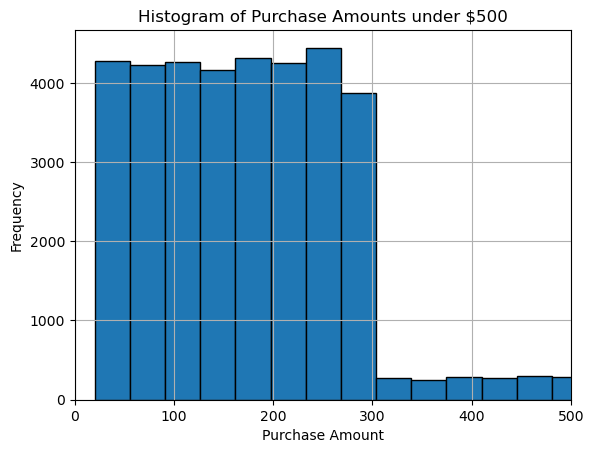

In [11]:
# Histogram of Purchase Amount
df['Purchase_Amount'].hist(bins='auto', edgecolor='black', linewidth=1)

# 3. Add labels and title for clarity
plt.title("Histogram of Purchase Amounts under $500")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.xlim(0, 500) # Changing the 500 will change the x-limit to a higher or lower purchase amount

# 4. Display the plot
plt.show()

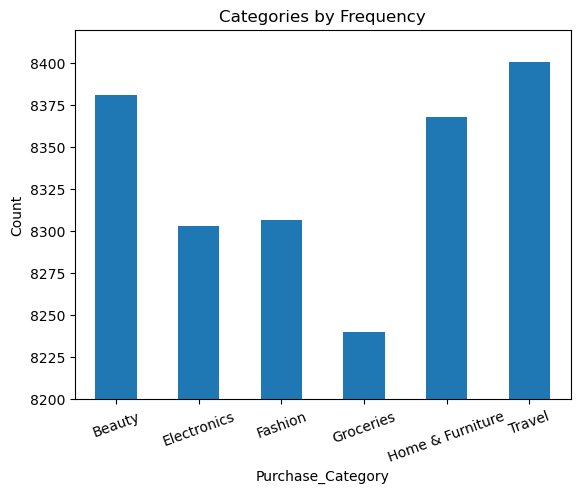

In [20]:
# Bar chart showing counts of purchases by Category
category_counts = df['Purchase_Category'].value_counts().sort_index().plot(kind='bar')

plt.title('Categories by Frequency')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.ylim(8200, 8420) # manually set the y-axis range so it zooms in on 8200–8500.
plt.show()

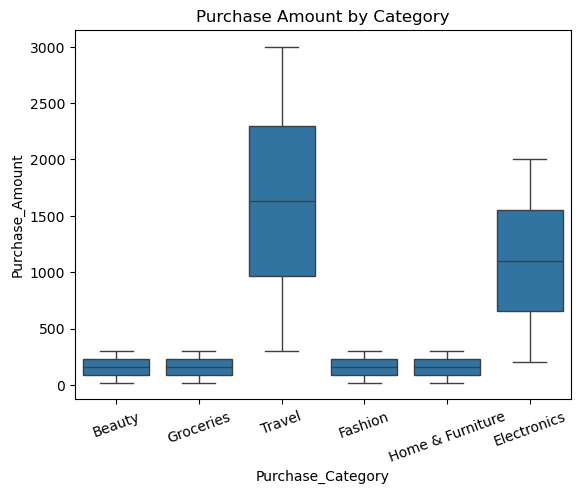

In [18]:
# Boxplot of Purchase Amount by Category
sns.boxplot(x=df['Purchase_Category'], y=df['Purchase_Amount'], data=df)
plt.title('Purchase Amount by Category')
plt.xticks(rotation=20)
plt.show()